# Using transformer LLMs (encoder models like MiniLM with sentence_transformers/sbert)

## Basic setup

In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer, SimilarityFunction
from tqdm import tqdm
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import networkx as nx
import itertools

from DataLoader import DataLoader

In [2]:
model = SentenceTransformer("all-MiniLM-L6-v2")
model.similarity_fn_name = SimilarityFunction.EUCLIDEAN

## Embed articles

In [3]:
articles = pd.read_csv('data/articles.tsv', sep='\t')

In [4]:
embeddings_array = model.encode(articles['article'], show_progress_bar=True)
embeddings = {}
for i, article in enumerate(articles['article']):
    embeddings[article] = embeddings_array[i]

Batches:   0%|          | 0/144 [00:00<?, ?it/s]

## Calculate all distances between articles

In [5]:
all_dists = []
for x in tqdm(articles['article']):
    for y in articles['article']:
        dist = model.similarity(embeddings[x], embeddings[y])
        all_dists.append((x, y, -float(dist[0,0])))
# save to pandas csv
df = pd.DataFrame(all_dists, columns=['article1', 'article2', 'dist'])
df

100%|██████████| 4604/4604 [04:30<00:00, 17.03it/s]


,article1,article2,dist
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,0.000000
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,%C3%85land,1.028989
2,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,%C3%89douard_Manet,1.049802
3,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,%C3%89ire,0.992522
4,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,%C3%93engus_I_of_the_Picts,1.048300
...,...,...,...
21196811,Zulu,Zionism,1.218069
21196812,Zulu,Zirconium,1.205033
21196813,Zulu,Zoroaster,1.148494
21196814,Zulu,Zuid-Gelders,1.276647


In [6]:
df.to_csv('article_dists.csv', index=False)

## Create distance-based graph

In [5]:
tqdm.pandas()

edges = pd.read_csv('data/links.tsv', sep='\t', names=['source', 'target'])
edges["distance"] = edges.progress_apply(lambda row: -float(model.similarity(embeddings[row['source']], embeddings[row['target']])[0,0]), axis=1)
edges

100%|██████████| 119882/119882 [00:02<00:00, 59571.16it/s]


,source,target,distance
0,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Bede,1.319600
1,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Columba,1.299342
2,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,D%C3%A1l_Riata,0.886729
3,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Great_Britain,1.318808
4,%C3%81ed%C3%A1n_mac_Gabr%C3%A1in,Ireland,1.328025
...,...,...,...
119877,Zulu,South_Africa,1.001839
119878,Zulu,Swaziland,1.059678
119879,Zulu,United_Kingdom,1.279462
119880,Zulu,Zambia,1.015284


In [6]:
edges.to_csv('links_distances.csv')

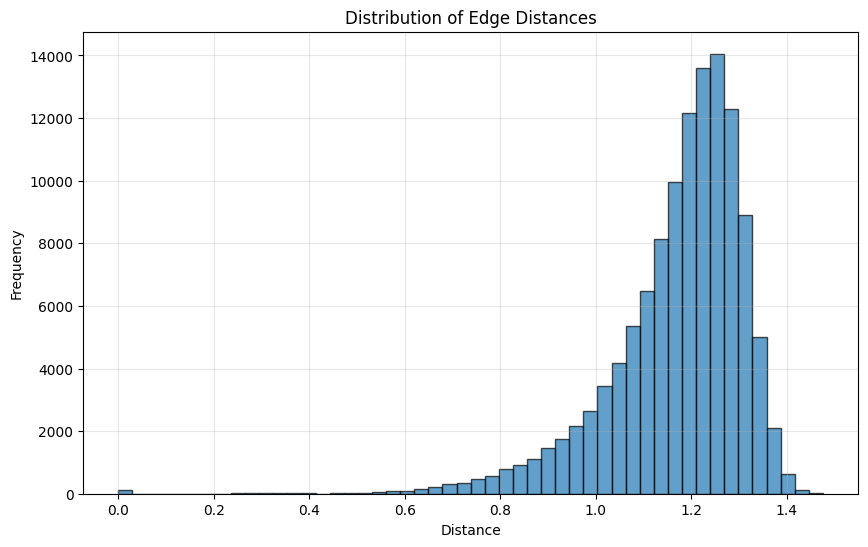

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(edges["distance"], bins=50, alpha=0.7, edgecolor='black')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Edge Distances')
plt.grid(True, alpha=0.3)
plt.show()

## Correlate LLM-distance-optimal paths with actual optimal paths

In [8]:
dataloader = DataLoader("data")
dataloader.load_paths("paths_finished.tsv")
dataloader.load_edges("links.tsv")

In [9]:
## Find paths that are optimal in LLM distance instead of 'simple' distance by number of clicks
G = nx.from_pandas_edgelist(edges, 'source', 'target', edge_attr='distance', create_using=nx.DiGraph())

In [10]:
no_in = [node for node in G.nodes if G.in_degree(node) == 0]
len(no_in)

457

In [11]:
G_path_llm = nx.DiGraph()


for node in tqdm(G):
    length, path = nx.single_source_dijkstra(G, node, weight='distance')
    for goal, dist in length.items():
        if dist is None:
            continue
        G_path_llm.add_edge(node, goal, distance=dist)

100%|██████████| 4592/4592 [04:10<00:00, 18.34it/s]


In [7]:
G_path_llm["Asia"]

NameError: name 'G_path_llm' is not defined

In [13]:
nx.to_pandas_edgelist(G_path_llm).to_csv('pairs_llm_distances.csv')

In [14]:
G_path_clicks = nx.DiGraph()

for node in tqdm(G):
    length, path = nx.single_source_dijkstra(G, node, weight=None)
    for goal, dist in length.items():
        if dist is None:
            continue
        G_path_clicks.add_edge(node, goal, distance=dist)

100%|██████████| 4592/4592 [06:18<00:00, 12.14it/s]


In [15]:
G_path_clicks["Asia"]

AtlasView({'Asia': {'distance': 0}, 'Abu_Dhabi': {'distance': 1}, 'Afghanistan': {'distance': 1}, 'Africa': {'distance': 1}, 'American_English': {'distance': 1}, 'Armenia': {'distance': 1}, 'Automobile': {'distance': 1}, 'Azerbaijan': {'distance': 1}, 'Baghdad': {'distance': 1}, 'Bah%C3%A1%27%C3%AD_Faith': {'distance': 1}, 'Bahrain': {'distance': 1}, 'Bangkok': {'distance': 1}, 'Bangladesh': {'distance': 1}, 'Beijing': {'distance': 1}, 'Beirut': {'distance': 1}, 'Bhutan': {'distance': 1}, 'Bible': {'distance': 1}, 'Black_Sea': {'distance': 1}, 'British_English': {'distance': 1}, 'Brunei': {'distance': 1}, 'Buddhism': {'distance': 1}, 'Cairo': {'distance': 1}, 'Cambodia': {'distance': 1}, 'Capital': {'distance': 1}, 'Caspian_Sea': {'distance': 1}, 'China': {'distance': 1}, 'Christianity': {'distance': 1}, 'Colombo': {'distance': 1}, 'Communism': {'distance': 1}, 'Computer': {'distance': 1}, 'Confucianism': {'distance': 1}, 'Continent': {'distance': 1}, 'Cyprus': {'distance': 1}, 'Damasc

In [16]:
nx.to_pandas_edgelist(G_path_clicks).to_csv('pairs_click_distances.csv')

## Correlate LLM-derived distances with Wikispeedia-derived distances

In [17]:
distances = pd.read_csv('semantics_distances.csv')

In [18]:
article_from = []
article_to = []
wikispeedia_dists = []
transformer_dists = []

for index, row in tqdm(distances.iterrows(), total=distances.shape[0]):
    if row['distance'] > 5:
        continue
    article_from.append(row['start'])
    article_to.append(row['goal'])
    wikispeedia_dists.append(row['distance'])
    transformer_dists.append(model.similarity(embeddings[row['start']], embeddings[row['goal']])[0,0])

100%|██████████| 140908/140908 [00:05<00:00, 26420.68it/s]


In [19]:
x = np.array(wikispeedia_dists)
y = np.array(transformer_dists)

print(x.shape, y.shape)

slope, intercept, r_value, p_value, std_err = stats.linregress(wikispeedia_dists, transformer_dists)
print(slope, intercept, r_value, p_value, std_err)

(139064,) (139064,)
-0.035258525257164934 -1.1700611632996303 -0.1962467326125337 0.0 0.0004724210395940611


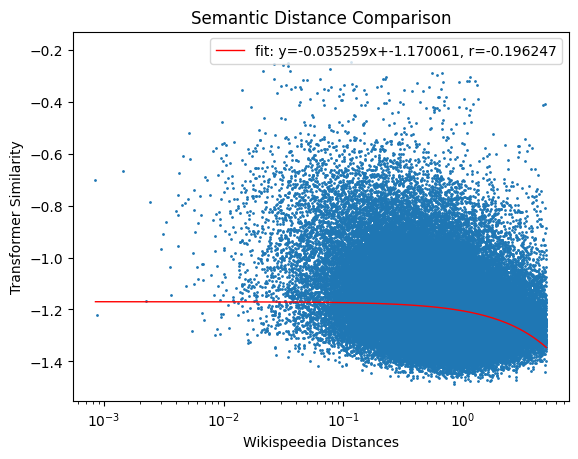

In [20]:
plt.scatter(wikispeedia_dists, transformer_dists, s=1)
plt.xlabel('Wikispeedia Distances')
plt.ylabel('Transformer Similarity')
plt.title('Semantic Distance Comparison')
plt.xscale('log')

# plot regression line (avoid log(0) by starting from the smallest positive x)
xmin = x[x > 0].min()
xmax = x.max()
xs = np.logspace(np.log10(xmin), np.log10(xmax), 200)
ys = slope * xs + intercept
plt.plot(xs, ys, color='red', linewidth=1, label=f'fit: y={slope:.6f}x+{intercept:.6f}, r={r_value:.6f}')
plt.legend()
plt.show()

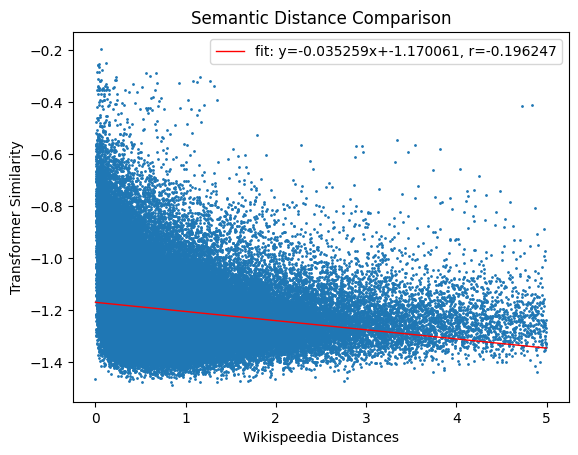

In [21]:
plt.scatter(wikispeedia_dists, transformer_dists, s=1)
plt.xlabel('Wikispeedia Distances')
plt.ylabel('Transformer Similarity')
plt.title('Semantic Distance Comparison')

# plot regression line across the data range
xmin = x.min()
xmax = x.max()
xs = np.linspace(xmin, xmax, 200)
ys = slope * xs + intercept
plt.plot(xs, ys, color='red', linewidth=1, label=f'fit: y={slope:.6f}x+{intercept:.6f}, r={r_value:.6f}')
plt.legend()
plt.show()